In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data

***Dataset***

In [247]:
df = pd.read_csv("bangladesh_student_performance_updated.csv")

***Analyzing the Dataset***

In [248]:
row, column = df.shape
print(f"Total Row: {row}")
print(f"Total Column: {column}")

Total Row: 2018
Total Column: 16


In [249]:
df.sample(5)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
1949,29/04/2018,M,19.0,Rural,GT3,Together,1,1,Teacher,Farmer,No,No,43677.0,1,2.72,2.33
1642,29/04/2018,M,19.0,Rural,GT3,Together,3,2,At_home,Teacher,No,No,55396.0,4,4.36,3.78
656,29/04/2018,M,17.0,Urban,GT3,Together,3,4,Health,Health,No,No,90219.0,5,3.68,3.00
186,29/04/2018,F,18.0,Urban,GT3,Together,3,4,Other,Health,No,No,90548.0,2,4.17,3.73
1420,29/04/2018,M,17.0,Rural,GT3,Together,0,2,Services,Health,No,No,36399.0,5,3.69,3.10


In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           1983 non-null   float64
 3   address       1983 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         1983 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   1983 non-null   float64
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(4), int64(3), object(9)
memory usage: 252.4+ KB


In [251]:
df.isnull().sum()

date             0
gender           0
age             35
address         35
famsize          0
Pstatus          0
M_Edu            0
F_Edu            0
M_Job           35
F_Job            0
relationship     0
smoker           0
tuition_fee     35
time_friends     0
ssc_result       0
hsc_result       0
dtype: int64

In [252]:
# all numerical features
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1983.000000,2018.000000,2018.000000,1983.000000,2018.00000,2018.000000,2018.000000
mean,17.980837,1.871160,2.174430,73045.274332,3.05996,3.788087,3.199177
std,0.825695,1.194206,1.252979,24102.016020,1.43919,0.622376,0.604526
min,17.000000,0.000000,0.000000,25102.000000,1.00000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53639.500000,2.00000,3.360000,2.780000
50%,18.000000,2.000000,2.000000,71343.000000,3.00000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91185.000000,4.00000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.00000,5.000000,5.000000


In [253]:
print(f"Toatl Duplicate Values: {df.duplicated().sum()}")

Toatl Duplicate Values: 0


# EDA

Text(0.5, 0.98, 'All Numerical Features')

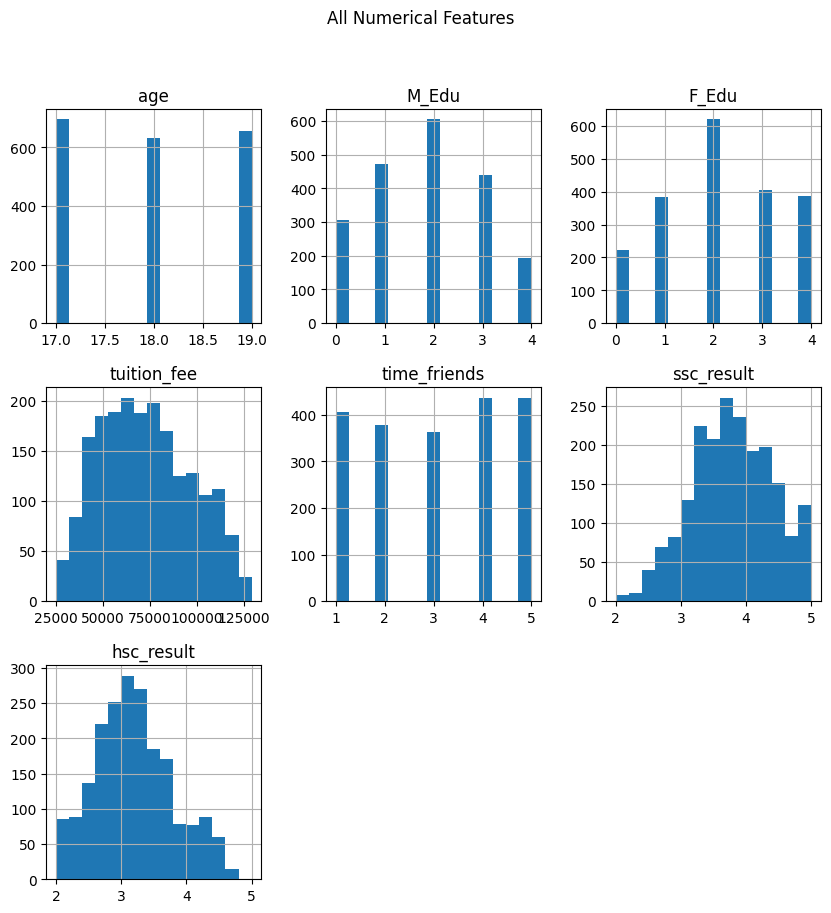

In [254]:
df.hist(bins=15, figsize=(10, 10))
plt.suptitle("All Numerical Features")

In [255]:
nuemrical_columns = ['age', 'tuition_fee', 'ssc_result', 'hsc_result']
df[nuemrical_columns].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,0.001015,-0.013061,-0.012592
tuition_fee,0.001015,1.000000,0.018385,0.041205
ssc_result,-0.013061,0.018385,1.000000,0.950178
hsc_result,-0.012592,0.041205,0.950178,1.000000


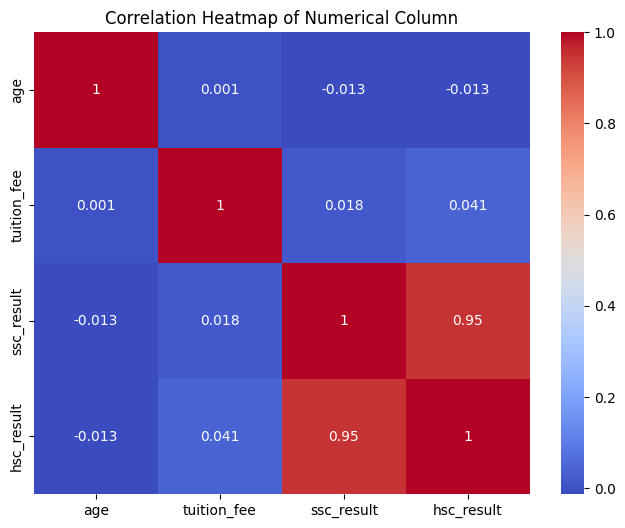

In [256]:
# correlation heatmap
plt.figure(figsize=(8,6))
plt.title("Correlation Heatmap of Numerical Column")

sns.heatmap(
    df[nuemrical_columns].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

# Pipelining

In [257]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor

***Preprocessing***

In [258]:
# catagorical features
nominal_catagory = ['gender', 'address', 'famsize', 'Pstatus', 'relationship', 'smoker', 'M_Job', 'F_Job']

'''
ordinal_catagory = ['M_Edu', 'F_Edu', 'time_friends']

M_edu_order = [0, 1, 2, 3, 4] # father's eduction order
F_edu_order = [0, 1, 2, 3, 4] # mother's education order
time_friends_order = [5, 4, 3, 2, 1] # time with friends order
'''

# numerical features
numerical_column = ['age', 'tuition_fee', 'ssc_result']

***Numerical Pipe***

In [259]:
numerical_transformers = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

numerical_transformers

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


***Catagorical Pipe***

In [260]:
# nominal features
nominal_transformers = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]
)

nominal_transformers

,steps,"[('imputer', ...), ('encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [261]:
# ordinal features
ordinal_transformers = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=[M_edu_order, F_edu_order, time_friends_order])),
        ('scaler', MinMaxScaler())
    ]
)

ordinal_transformers

,steps,"[('imputer', ...), ('encoder', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,"[['0', '1', ...], ['0', '1', ...], ...]"


In [262]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformers, numerical_column),
        ('nominal', nominal_transformers, nominal_catagory),
        # ('ordinal', ordinal_transformers, ordinal_catagory)
    ],
    remainder='passthrough'
)

preprocessor

,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [263]:
x = df.drop(['date', 'hsc_result'], axis=1)
y = df['hsc_result']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Pipe Line

***Linear Regression***

In [264]:
lr_pipe = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

lr_pipe

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


***Training***

In [265]:
lr_pipe.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


***Prediction***

In [266]:
x_test.sample(3)

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
39,M,18.0,Rural,LE3,Apart,3,2,At_home,Health,No,No,69478.0,4,3.22
453,F,19.0,Rural,GT3,Together,4,2,Services,Business,No,No,88952.0,4,4.10
994,M,18.0,Rural,GT3,Together,4,0,Services,Farmer,No,No,66553.0,5,4.73


In [267]:
lr_pipe.predict(x_test)

array([3.22566531, 3.75147018, 3.83019613, 4.00664186, 3.90886468,
       3.33301608, 3.9843285 , 2.54037997, 1.97886626, 3.27239028,
       3.67549746, 2.91990239, 3.23829796, 4.27797546, 3.03907632,
       2.67683989, 3.71729372, 3.45240833, 2.8064922 , 2.96057683,
       2.82062305, 3.20485147, 2.99957398, 3.21864928, 1.89881831,
       2.58370593, 3.18675035, 3.82959511, 3.08845188, 3.94801852,
       2.39854271, 3.94466671, 4.31696495, 2.56460476, 3.19397834,
       3.26413536, 2.75935124, 3.65848872, 2.48692797, 2.60907848,
       3.07614707, 2.97405288, 3.73760615, 2.76965129, 2.17795697,
       3.0682365 , 2.62107646, 2.60926091, 4.03558054, 3.26099047,
       3.07457897, 3.45268988, 4.23316558, 3.63562822, 3.07047904,
       3.19897028, 3.29199946, 2.67475419, 3.81647227, 2.67135675,
       3.00589862, 2.76737407, 2.49028194, 4.43360442, 2.5597574 ,
       3.21127693, 3.96661533, 2.67087186, 3.03353973, 3.22560591,
       3.03057043, 2.72163419, 2.61374344, 3.63605177, 3.07885

***SGD Regression***

In [268]:
sgd_pipe = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', SGDRegressor())
    ]
)

sgd_pipe

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [269]:
sgd_pipe.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('nominal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [270]:
sgd_pipe.predict(x_test)

array([3.21517805, 3.76781754, 3.82780211, 3.94134204, 3.83447371,
       3.3371278 , 3.94261313, 2.50883697, 1.95880841, 3.27959132,
       3.67565516, 2.92844806, 3.23774642, 4.27403999, 3.05568781,
       2.6345434 , 3.7203831 , 3.39470647, 2.8188022 , 2.92850394,
       2.82007229, 3.21778762, 2.95432074, 3.18575808, 1.90183276,
       2.49652303, 3.20740834, 3.83231978, 3.05492845, 3.95141372,
       2.39972672, 3.95841436, 4.26960309, 2.5770423 , 3.214367  ,
       3.2893789 , 2.76310395, 3.67491049, 2.50117432, 2.61162633,
       3.09845246, 2.98098984, 3.74115926, 2.77310108, 2.12584252,
       3.084313  , 2.64095016, 2.59396429, 3.98026507, 3.22235954,
       3.06110848, 3.45273301, 4.20042806, 3.61306661, 3.05295773,
       3.15197019, 3.30470649, 2.66843333, 3.82124325, 2.60691348,
       3.02369084, 2.76912073, 2.47474114, 4.44814745, 2.57637632,
       3.21675212, 3.92835037, 2.67894389, 3.03904699, 3.1968511 ,
       3.02970942, 2.73252075, 2.61165159, 3.6494851 , 3.07008

# Error Matrics

In [271]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

In [272]:
y_prediction = lr_pipe.predict(x_test)

In [273]:
mse = mean_absolute_error(y_test, y_prediction)
rmse = root_mean_squared_error(y_test, y_prediction)
mae = mean_absolute_error(y_test, y_prediction)
r2s = r2_score(y_test, y_prediction)

In [274]:
print(f"MSE: {round(mse,4)}")
print(f"RMSE: {round(rmse,4)}")
print(f"MAE: {round(mae,4)}")
print(f"R2 Score: {round(r2s,4)}")

MSE: 0.1114
RMSE: 0.1425
MAE: 0.1114
R2 Score: 0.9459
